## Introduction to Feature Selection

What is Feature Selection ?
- Process of Identifying and retaining the most relevant features (input variables) in a dataset while discarding irrelevant or redundant once

##### Why is Feature Selection Important


- Improves Model Performance
- Reduces Overfitting
- Enhances Interpretability
- Increases Computational Efficiency

##### Why to use Feature Selection ?
- High-Dimensional Data
- Correlated Features
- Reducing Complexity

---

#### Techniques for Feature Selection

- **Filter Methods:** Evaluate the relevance of features by analyzing their statistical properties in relation to the target variable 
  - Example: Pearson Cofficient Correlation, Mutual Information
  - *When to Use*: Quick evaluation of features before training a model

- **Wrapper Methods:** Iteratively select features by training and evaluating a model
  - Example: Forward Selection| Backward Elimination
  - *When to Use:* Useful when feature interactions are important ut computationally expensive

- **Embedded Methods**
  - Performs feature selection as part of model training process
  - *Example:* Lasso Regression, Tree-Based Models
  - When to use: Effective when training tree-based models or regularized regression

---

### Hands-On 
 - Use Correlation and Mutual information to select important features from a dataset
 - Apply a tree-based model (e.g Random Forest) to identify the most important features

In [53]:
from sklearn.datasets import load_diabetes
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression


In [54]:
# Load the dataset
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

In [55]:
# Display Dataset information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB
None


In [56]:
print(df.describe())

                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01   
25%   -3.729927e-02 -4.464164e-02 -3.422907e-02 -3.665608e-02 -3.424784e-02   
50%    5.383060e-03 -4.464164e-02 -7.283766e-03 -5.670422e-03 -4.320866e-03   
75%    3.807591e-02  5.068012e-02  3.124802e-02  3.564379e-02  2.835801e-02   
max    1.107267e-01  5.068012e-02  1.705552e-01  1.320436e-01  1.539137e-01   

                 s2            s3            s4            s5            s6  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean   3.918434e-17 -5.777179e-18 -9.042540e-18  9.293722e-17  1.130318e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.

In [57]:
print(df.head())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


### Correlation Matrix for Feature Selction

In [58]:
# Feature Selection using Correlation
correlation_matrix = df.corr()

<Axes: >

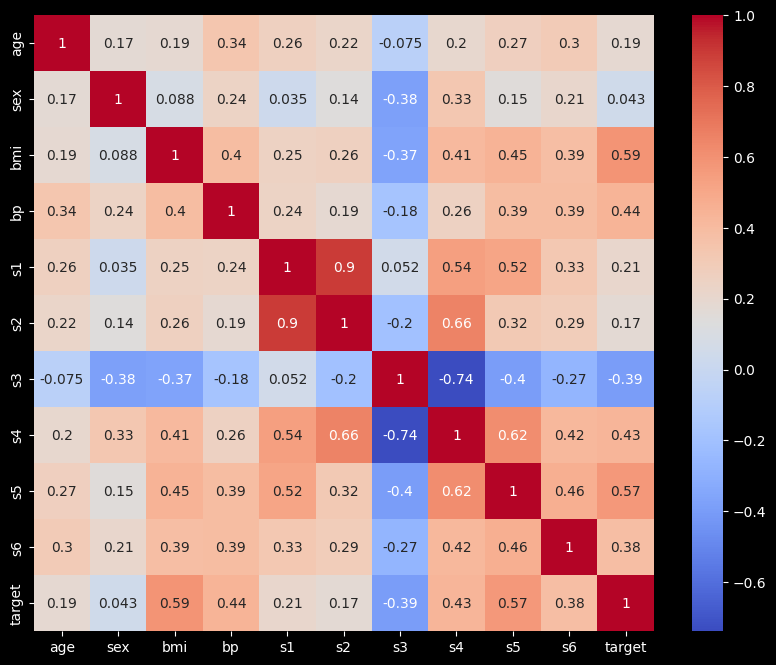

In [59]:
# Plot Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")

### Feature selection with high correlation to the target

In [60]:
# Select features with high correlation to the target
correlated_features = correlation_matrix['target'].sort_values(ascending=False)
print("Features Most Correlated with Targets")
print(correlated_features)

Features Most Correlated with Targets
target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
s3       -0.394789
Name: target, dtype: float64


In [61]:
# Seperate features and target
X = df.drop(columns=['target'])
y = df['target']

### Creating Mutual Information

In [62]:
# Calculate mutual information
mutual_info = mutual_info_regression(X,y)

In [64]:
# Create a dataframe for better visualization
mi_df = pd.DataFrame({'Feature':X.columns, "Mutual Information":mutual_info})
mi_df = mi_df.sort_values(by="Mutual Information", ascending=False)
print("Mutual Information Scores:")
print(mi_df)

Mutual Information Scores:
  Feature  Mutual Information
2     bmi            0.175701
8      s5            0.146548
9      s6            0.121690
7      s4            0.103869
6      s3            0.065897
4      s1            0.063416
3      bp            0.060997
1     sex            0.034185
5      s2            0.011522
0     age            0.000000


### Using Random Forest

In [65]:
from sklearn.ensemble import RandomForestRegressor

In [66]:
model = RandomForestRegressor(random_state=42)
model.fit(X,y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [67]:
# Get Feature Importance
feature_importance = model.feature_importances_
importance_df = pd.DataFrame({'Feature':X.columns, 'Importance':feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

In [68]:
print("Feature Importance from Random Forest:")
print(importance_df)

Feature Importance from Random Forest:
  Feature  Importance
8      s5    0.315629
2     bmi    0.276249
3      bp    0.087085
9      s6    0.070775
0     age    0.057496
5      s2    0.055368
6      s3    0.051191
4      s1    0.047251
7      s4    0.027056
1     sex    0.011901


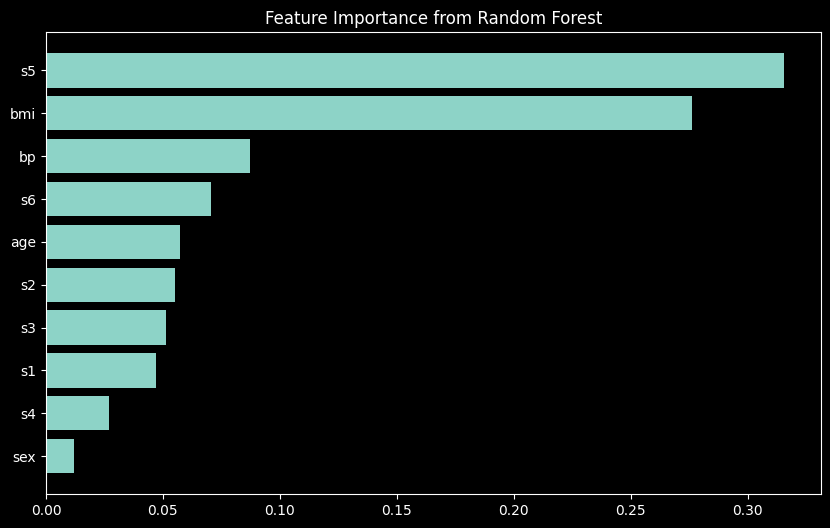

In [72]:
# Plot Feature Importance
plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance from Random Forest")
plt.show()